# Lab 6.02 - Regression analysis

In [1]:
# Package imports
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Dataframe
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz
from sklearn.linear_model import LinearRegression

## Exercise 2: Flemish agricultural and horticultural businesses

1. Use the dataset agriculture flanders.csv. The file contains data about agricultural and horticultural businesses in Flanders

    Source: Departement Landbouw en Visserij op basis van StatBel

In [2]:
farms = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/agriculture%20flanders.csv', delimiter = ";", decimal=',')
# Show the first few records of the Data Frame
farms.head()

,year,number_of_farms,average_area_per_farm_(ha)
0,1980,75706,8.38
1,1981,73292,8.58
2,1982,71255,8.79
3,1983,69807,8.94
4,1984,68083,9.15


2. What are the datatypes for each of the columns.

In [3]:
farms.dtypes

year                            int64
number_of_farms                 int64
average_area_per_farm_(ha)    float64
dtype: object

3. Draw a scatter plot of the number of farms versus the year.


<Axes: xlabel='year', ylabel='number_of_farms'>

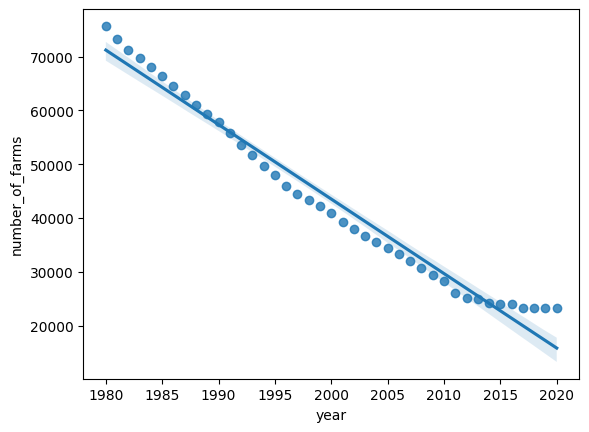

In [4]:
sns.regplot(farms, x='year', y="number_of_farms")

4. Is there a positive / negative relationship between year and number_of_farms?

    $R = -0.9861066349492859$

In [ ]:
np.corrcoef(farms.year, farms.number_of_farms)[0][1]

# Negative

# R < 0 => dalend
# |R| > .98 => extreem sterk verband jaar en number_of_farms

np.float64(-0.9861066349492859)

6. Is there a strong relationship between year and 'number_of_farms'?

    $R^2 = 0.9724062954910041$

In [ ]:
# extremely strong

# 97% is afhankelijk

R² = 0.9724062954910041


7. Draw a scatter plot of the 'average_area_per_farm_(ha)' versus the year.

<Axes: xlabel='year', ylabel='average_area_per_farm_(ha)'>

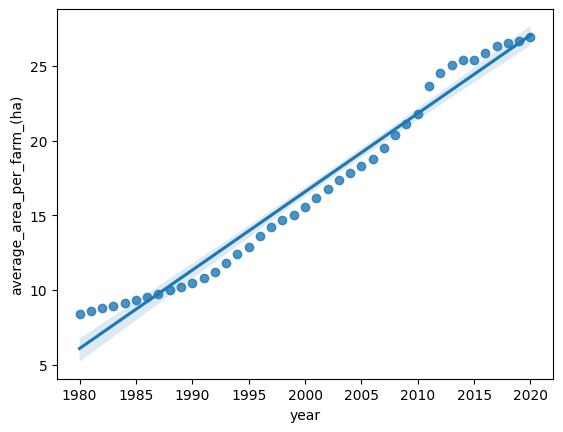

In [6]:
sns.regplot(farms, x='year', y="average_area_per_farm_(ha)")

8. What will be the 'average_area_per_farm_(ha)' in 2035?

Average area in 2035 = 34.91987804878045

In [7]:
b1, b0 = np.polyfit(x=farms['year'], y=farms['average_area_per_farm_(ha)'], deg = 1)


print(f"y = {b0} + {b1} * x")

average_area_2035 = b1 * 2035 + b0
print(average_area_2035)

y = -1031.8951916376452 + 0.5242334494773592 * x
34.919878048780674


8. Calculate the total agricultural area for each year.   
Calculate for each year the change of the total area relative to 1980.  
Make a plot.

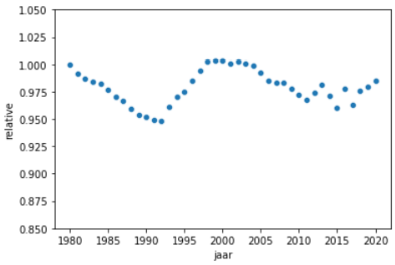


In [13]:
farms['total_land_area'] = farms['average_area_per_farm_(ha)'] * farms['number_of_farms']
# land_in_1980 = farms[farms['year'] == 1980]['total_land_area'].to_numpy()[0]
land_in_1980 = farms.iloc[0, 3]
farms['relative'] = (farms['total_land_area'] - land_in_1980) / land_in_1980
farms.head()


,year,number_of_farms,average_area_per_farm_(ha),total_land_area,relative
0,1980,75706,8.38,634416.28,0.000000
1,1981,73292,8.58,628845.36,-0.008781
2,1982,71255,8.79,626331.45,-0.012744
3,1983,69807,8.94,624074.58,-0.016301
4,1984,68083,9.15,622959.45,-0.018059


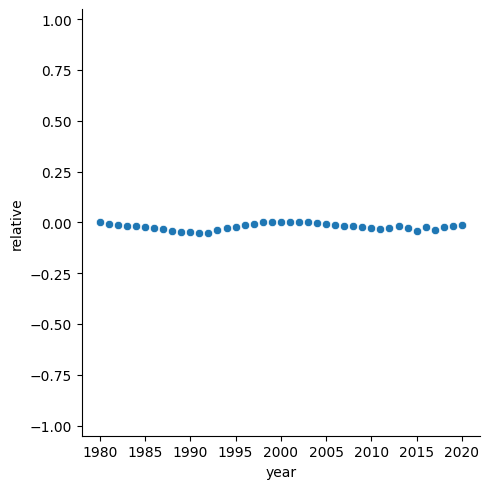

In [14]:
p = sns.relplot(data=farms, x='year', y='relative')

p.set(ylim = (-1.05, 1.05))